In [ ]:
# #to fetch ic5o with header  run the bewlow  command in terminal 
# #head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
# #grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv


# import os
# os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1')

# import pandas as pd

# # Load both datasets
# df1 = pd.read_csv("ABL1_CHEMBL1862_IC50_chembl_Wsmile.csv")
# df2 = pd.read_csv("ABL1_P00519_IC50_only.csv")


# df2 = df2[["SMILES", "Affinity Value"]]
# df2.columns = ["smiles", "standard_value"]  # rename for consistency

# common_smiles = set(df1["smiles"]) & set(df2["smiles"])

# # Filter rows with common SMILES
# df1_common = df1[df1["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df1"})
# df2_common = df2[df2["smiles"].isin(common_smiles)][["smiles", "standard_value"]].rename(columns={"standard_value": "IC50_df2"})

# # Merge on SMILES
# merged = pd.merge(df1_common, df2_common, on="smiles")

# # print(merged)  # Show first 10 entries

# print(f"Number of common SMILES: {len(common_smiles)}")
# # print(list(common_smiles)[:10])  # Print first 10 for preview

# # # Combine the two datasets
# combined_df = pd.concat([df1, df2], ignore_index=True)
# combined_df


# # # Drop entries with missing SMILES or IC50
# combined_df = combined_df.dropna(subset=["smiles", "standard_value"])
# combined_df
# # # Convert IC50 values to numeric
# combined_df["standard_value"] = pd.to_numeric(combined_df["standard_value"], errors="coerce")
# # combined_df
# # # Drop any rows with NaNs in standard_value after conversion
# combined_df = combined_df.dropna(subset=["standard_value"])
# combined_df

# # # Keep only the entry with the lowest IC50 for each SMILES
# min_ic50_df = combined_df.loc[combined_df.groupby("smiles")["standard_value"].idxmin()]
# min_ic50_df
# # # Select only relevant columns
# final_df = min_ic50_df[["smiles", "standard_value"]].reset_index(drop=True)

# # # Save to a new CSV file
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)



Number of common SMILES: 97


In [3]:
import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1')
final_df= pd.read_csv("dedeuplicated_combined_ic50.csv")
##check for duplication
# Ensure SMILES column is treated as string
final_df["smiles"] = final_df["smiles"].astype(str)

# Check for duplicates in the 'smiles' column
duplicates = final_df[final_df.duplicated("smiles", keep=False)]  # keep=False shows *all* duplicates

# Print number and preview of duplicates
print(f"Total duplicate SMILES entries: {len(duplicates)}")
print(duplicates.head())




Total duplicate SMILES entries: 0
Empty DataFrame
Columns: [smiles, standard_value, is_valid, label]
Index: []


In [30]:
final_df


,smiles,standard_value
0,Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0
1,C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...,390.0
2,C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1,750.0
3,C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1,4900.0
4,C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1,4700.0
...,...,...
119,c1ccc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0
120,c1ccc(Nc2ncnc3[nH]ccc23)cc1,790.0
121,c1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,390.0
122,c1cncc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)c1,750.0


In [31]:
from rdkit import Chem
import pandas as pd


# Check for invalid SMILES
def check_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None
final_df['is_valid'] = final_df['smiles'].apply(check_smiles)

# Report
invalid_smiles = final_df[~final_df['is_valid']]
print(f"Total SMILES: {len(final_df)}")
print(f"Invalid SMILES: {len(invalid_smiles)}")

if not invalid_smiles.empty:
    print("List of invalid SMILES:")
    print(invalid_smiles[['smiles']])
else:
    print("✅ All SMILES are valid.")


# remove the invalid using
final_df = final_df[final_df['is_valid']]
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)

Total SMILES: 124
Invalid SMILES: 0
✅ All SMILES are valid.


In [32]:
final_df

,smiles,standard_value,is_valid
0,Brc1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0,True
1,C(Cn1cc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)nn1)c1cc...,390.0,True
2,C(Oc1ccc(Nc2ncnc3[nH]ccc23)cc1)c1ccccc1,750.0,True
3,C1CN(CCO1)c1ccc(Nc2ncnc3[nH]ccc23)cc1,4900.0,True
4,C1CN(CCO1)c1cccc(Nc2ncnc3[nH]ccc23)c1,4700.0,True
...,...,...,...
119,c1ccc(COc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,750.0,True
120,c1ccc(Nc2ncnc3[nH]ccc23)cc1,790.0,True
121,c1ccc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)cc1,390.0,True
122,c1cncc(Oc2ccc(Nc3ncnc4[nH]ccc34)cc2)c1,750.0,True


In [33]:
#classification actives/inactives

# 2) Convert IC50 column to numeric (in case there were strings)
final_df['standard_value'] = pd.to_numeric(final_df['standard_value'], errors='coerce')

# 3) Add classification column
final_df['label'] = (final_df['standard_value'] < 100).astype(int)
# 1 = Active, 0 = Inactive


# 4) Quick sanity check
print(final_df[['standard_value', 'label']].head())

# 5) (Optional) Save back out
final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)


   standard_value  label
0           750.0      0
1           390.0      0
2           750.0      0
3          4900.0      0
4          4700.0      0


In [35]:
# Count how many of each
counts = final_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(final_df))

Inactives (0): 91
Actives   (1): 33
124


In [ ]:
#SMILE AUGMENTATION FOR TTBK
from rdkit import Chem
from rdkit.Chem import MolToSmiles
import pandas as pd

def random_smiles(smiles, n=5):
    mol = Chem.MolFromSmiles(smiles)
    return [MolToSmiles(mol, doRandom=True) for _ in range(n)]

# Load your small-data TTBK DataFrame with columns: smiles, label
ttbk_df = pd.read_csv("dedeuplicated_combined_ic50.csv")

augmented_rows = []
for _, row in ttbk_df.iterrows():
    smi, lbl = row['smiles'], row['label']
    for rnd_smi in random_smiles(smi, n=5):
        augmented_rows.append({'smiles': rnd_smi, 'label': lbl})

aug_df = pd.DataFrame(augmented_rows)
# Combine with the original
ttbk_augmented = pd.concat([ttbk_df, aug_df], ignore_index=True)
ttbk_augmented.to_csv("trial.csv")



In [42]:
# Count how many of each
counts = aug_df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(aug_df))

Inactives (0): 455
Actives   (1): 165
620


In [7]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

def load_and_clean(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"ERROR loading data: {e}")
        return None
    if not {'smiles', 'label'}.issubset(df.columns):
        print(f"ERROR: Required columns missing: {df.columns.tolist()}")
        return None
    df = df.dropna(subset=['smiles', 'label'])
    df = df[df['smiles'].str.strip().ne('')].copy()
    df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)
    print(f"Loaded {len(df)} clean entries; labels: {sorted(df['label'].unique())}")
    return df

def validate_smiles(df, sample_n=500, threshold=0.9):
    smpls = df['smiles'].sample(min(sample_n, len(df)), random_state=42)
    valid = smpls.apply(lambda s: Chem.MolFromSmiles(s) is not None).mean()
    print(f"SMILES valid on sample: {valid:.1%}")
    if valid < threshold:
        df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)].copy()
        print(f"Filtered invalid SMILES; remaining: {len(df)}")
    return df

def split_and_test(df):
    y = df['label'].values
    min_cls = np.min(np.bincount(y))
    strat = y if min_cls >= 2 else None
    if strat is None:
        print("WARNING: Cannot stratify; some classes with <2 samples")
    X_train, X_test, y_train, y_test = train_test_split(
        df['smiles'].values, y, test_size=0.2, stratify=strat, random_state=42
    )
    ok = sum(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048) is not None 
             for s in X_train[:5])
    print(f"FP test: {ok}/5 successful")
    return X_train, X_test, y_train, y_test

def gen_fps(smiles, radius=2, nbits=2048):
    fps, idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            if bit:
                fps.append(np.array(bit))
                idx.append(i)
    return np.array(fps), idx

from collections import Counter

def apply_smote(X_fp, y, imbalance_thresh=0.5):
    class_counts = Counter(y)
    if len(class_counts) <= 1:
        print("Only one class present, skipping SMOTE")
        return X_fp, y

    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)
    ratio = class_counts[minority_class] / class_counts[majority_class]

    print(f"Class distribution before SMOTE: {dict(class_counts)}")
    
    if ratio < imbalance_thresh:
        print("Applying SMOTE...")
        minority_count = class_counts[minority_class]
        k_neighbors = min(5, max(1, minority_count - 1))  # ensure at least 1
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        return sm.fit_resample(X_fp, y)

    print("SMOTE not needed")
    return X_fp, y


def pipeline(path):
    df = load_and_clean(path)
    if df is None: return
    df = validate_smiles(df)
    X_train, X_test, y_train, y_test = split_and_test(df)
    X_tr_fp, tr_idx = gen_fps(X_train)
    if not len(X_tr_fp):
        print("ERROR: No valid fingerprints generated")
        return
    y_tr = y_train[tr_idx]
    X_train_bal, y_train_bal = apply_smote(X_tr_fp, y_tr)
    print(f"Train size: {len(y_tr)} → {len(y_train_bal)} after SMOTE")
    return {
        'df_clean': df,
        'X_train': X_train_bal, 'y_train': y_train_bal,
        'X_test': gen_fps(X_test)[0], 'y_test': y_test
    }

if __name__ == "__main__":
    print("Running pipeline...")
    res = pipeline("dedeuplicated_combined_ic50.csv")
    if res:
        print("Pipeline completed.")
        print(res['df_clean'][['smiles','label']].head())


Running pipeline...
Loaded 4620 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {1: 1880, 0: 1816}
SMOTE not needed
Train size: 3696 → 3696 after SMOTE
Pipeline completed.
                                              smiles  label
0  Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...      1
1  Brc1ccc(NC(=O)[C@@H]2C[C@@H](CN2)n2cc(nn2)-c2c...      1
2  Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1c...      1
3  Brc1ccc(cc1)C(=O)N1CCN(CC1)C(=O)c1ccc(cc1)-c1n...      0
4            Brc1ccc2[nH]c-3c(CC(=O)Nc4ccccc-34)c2c1      0


In [8]:
if res:
    # Save cleaned dataset
    res['df_clean'].to_csv("df_clean.csv", index=False)

    # Save train and test features/labels as readable CSVs
    pd.DataFrame(res['X_train']).to_csv("X_train.csv", index=False)
    pd.DataFrame(res['y_train'], columns=["label"]).to_csv("y_train.csv", index=False)
    pd.DataFrame(res['X_test']).to_csv("X_test.csv", index=False)
    pd.DataFrame(res['y_test'], columns=["label"]).to_csv("y_test.csv", index=False)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(res['X_train'], res['y_train'])

preds = model.predict(res['X_test'])
print(classification_report(res['y_test'], preds))


              precision    recall  f1-score   support

           0       0.90      0.93      0.91       454
           1       0.93      0.90      0.91       470

    accuracy                           0.91       924
   macro avg       0.91      0.91      0.91       924
weighted avg       0.91      0.91      0.91       924



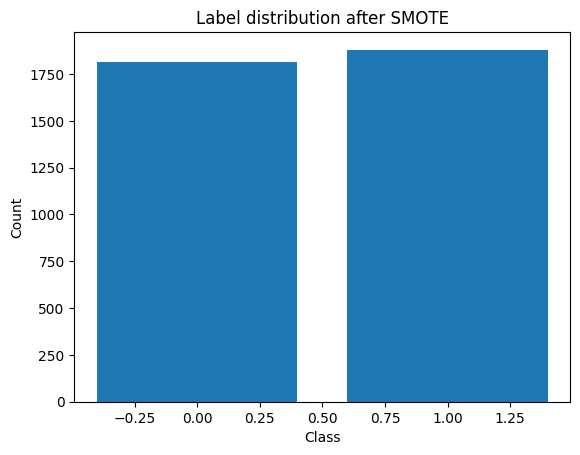

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(res['y_train'])
plt.bar(counts.keys(), counts.values())
plt.title("Label distribution after SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = RandomForestClassifier(random_state=42)
X = np.concatenate([res['X_train'], res['X_test']])
y = np.concatenate([res['y_train'], res['y_test']])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='f1_macro')
print(f"CV F1-macro scores: {scores}")
print(f"Mean F1: {scores.mean():.3f} ± {scores.std():.3f}")


CV F1-macro scores: [0.92424207 0.93290012 0.92748841 0.92423355 0.93613814]
Mean F1: 0.929 ± 0.005


In [12]:


from xgboost import XGBClassifier
model = XGBClassifier()
scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
print(f"XGB CV F1: {scores.mean():.3f} ± {scores.std():.3f}")


XGB CV F1: 0.921 ± 0.006


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, matthews_corrcoef
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# 1) PREPARE DATA — split into training and hold‑out test set
#    ensures test set is never used during parameter tuning
X = np.concatenate([res['X_train'], res['X_test']])
y = np.concatenate([res['y_train'], res['y_test']])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

# 2) DEFINE MODELS AND PARAMETER GRIDS for nested CV
#    each grid will be searched with a 5‑fold inner loop
models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, devices="0"),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    "NaiveBayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(
        tree_method="gpu_hist",      # GPU-accelerated histogram algorithm
        predictor="gpu_predictor",   # use GPU for inferences too
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}
param_grids = {
    "CatBoost": {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 300]
    },
    "SVM": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    },
    "KNN": {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance']
    },
    "NaiveBayes": {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    "XGBClassifier": {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 300]
    }
}
print(f"[MODELS] Prepared {len(models)} estimators with parameter grids")

# 3) SET UP outer CV splitter for consistency (not used directly since we have a hold‑out test)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("[CV] Stratified 5‑fold configured for inner GridSearchCV")

def tune_and_evaluate(name, estimator, param_grid):
    """
    Performs:
    - Inner 5‑fold GridSearchCV on X_train/y_train to find best hyperparameters
    - Fits best estimator on full X_train
    - Evaluates on hold‑out X_test/y_test
    - Computes precision, recall (sensitivity), specificity, MCC
    - Saves the best model to disk
    """
    print(f"\n----- {name} Grid Search & Evaluation -----")
    
    # 3a) Inner grid search
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=outer_cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"[GRID] Best params for {name}: {grid.best_params_}")
    print(f"[GRID] Best CV F1‑macro: {grid.best_score_:.3f}")
    
    # 3b) Fit best estimator on full training data
    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)
    print(f"[FIT] Trained {name} on all {X_train.shape[0]} training samples")
    
    # 3c) Predict on hold‑out test set
    y_pred = best_model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred, labels=[0, 1]
    ).ravel()
    
    # 3d) Compute metrics
    precision   = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    print(f"[TEST] Precision: {precision:.3f}")
    print(f"[TEST] Sensitivity (Recall): {sensitivity:.3f}")
    print(f"[TEST] Specificity: {specificity:.3f}")
    print(f"[TEST] MCC: {mcc:.3f}")
    
    # 3e) Save the best model
    fname = f"{name.lower()}_best_model.pkl"
    joblib.dump(best_model, fname)
    print(f"[SAVE] {name} model saved to {fname}")
    
    return {
        "Model": name,
        "Best_Params": grid.best_params_,
        "CV_F1_Macro": grid.best_score_,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc
    }

# 4) RUN tuning & evaluation for all models
results = []
for name, model in models.items():
    grid_results = tune_and_evaluate(name, model, param_grids[name])
    results.append(grid_results)

# 5) SUMMARIZE all results
df_results = pd.DataFrame(results)
print("\n=== All Models Summary ===")
print(df_results.to_string(index=False))


[DATA] 3696 train samples, 924 test samples
[MODELS] Prepared 5 estimators with parameter grids
[CV] Stratified 5‑fold configured for inner GridSearchCV

----- CatBoost Grid Search & Evaluation -----
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[GRID] Best params for CatBoost: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
[GRID] Best CV F1‑macro: 0.923
[FIT] Trained CatBoost on all 3696 training samples
[TEST] Precision: 0.939
[TEST] Sensitivity (Recall): 0.915
[TEST] Specificity: 0.938
[TEST] MCC: 0.853
[SAVE] CatBoost model saved to catboost_best_model.pkl

----- SVM Grid Search & Evaluation -----
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[GRID] Best params for SVM: {'svc__C': 10, 'svc__gamma': 'scale'}
[GRID] Best CV F1‑macro: 0.908
[FIT] Trained SVM on all 3696 training samples
[TEST] Precision: 0.935
[TEST] Sensitivity (Recall): 0.894
[TEST] Specificity: 0.936
[TEST] MCC: 0.830
[SAVE] SVM model saved to svm_best_model.pkl

----- KNN Grid S

/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:50:25] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:50:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [20:50:26] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packa

In [2]:
import pandas as pd

df = pd.read_csv('resampled.csv', sep='\t', header=None)
unique_smiles = df[0].nunique()
print(f"Unique SMILES: {unique_smiles} / Total Rows: {len(df)}")


FileNotFoundError: [Errno 2] No such file or directory: 'resampled.csv'